In [1]:
# Upload required CSV files in Google Colab

from google.colab import files

uploaded = files.upload()

Saving customer_churn.csv to customer_churn.csv
Saving sales_data.csv to sales_data.csv


In [2]:
# Import required libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully")

Libraries imported successfully


In [3]:
# Load datasets using pandas

sales_df = pd.read_csv("sales_data.csv")
customer_df = pd.read_csv("customer_churn.csv")

print("Datasets loaded successfully")

# Display first 5 rows
sales_df.head()

Datasets loaded successfully


,Date,Product,Quantity,Price,Customer_ID,Region,Total_Sales
0,2024-01-01,Phone,7,37300,CUST001,East,261100
1,2024-01-02,Headphones,4,15406,CUST002,North,61624
2,2024-01-03,Phone,2,21746,CUST003,West,43492
3,2024-01-04,Headphones,1,30895,CUST004,East,30895
4,2024-01-05,Laptop,8,39835,CUST005,North,318680


In [4]:
# Check shape of datasets

print("Sales Dataset Shape:", sales_df.shape)
print("Customer Dataset Shape:", customer_df.shape)

# Check column names
print("\nSales Columns:")
print(sales_df.columns)

print("\nCustomer Columns:")
print(customer_df.columns)

# Check missing values
print("\nMissing Values in Sales Dataset:")
print(sales_df.isnull().sum())

print("\nMissing Values in Customer Dataset:")
print(customer_df.isnull().sum())

Sales Dataset Shape: (100, 7)
Customer Dataset Shape: (500, 9)

Sales Columns:
Index(['Date', 'Product', 'Quantity', 'Price', 'Customer_ID', 'Region',
       'Total_Sales'],
      dtype='object')

Customer Columns:
Index(['CustomerID', 'Tenure', 'MonthlyCharges', 'TotalCharges', 'Contract',
       'PaymentMethod', 'PaperlessBilling', 'SeniorCitizen', 'Churn'],
      dtype='object')

Missing Values in Sales Dataset:
Date           0
Product        0
Quantity       0
Price          0
Customer_ID    0
Region         0
Total_Sales    0
dtype: int64

Missing Values in Customer Dataset:
CustomerID          0
Tenure              0
MonthlyCharges      0
TotalCharges        0
Contract            0
PaymentMethod       0
PaperlessBilling    0
SeniorCitizen       0
Churn               0
dtype: int64


In [5]:
# Remove duplicate rows if any

sales_df = sales_df.drop_duplicates()
customer_df = customer_df.drop_duplicates()

print("Duplicates removed successfully")

Duplicates removed successfully


In [6]:
# Convert Date column to datetime format

sales_df["Date"] = pd.to_datetime(sales_df["Date"])

# Extract year and month
sales_df["Year"] = sales_df["Date"].dt.year
sales_df["Month"] = sales_df["Date"].dt.month

print("Date conversion completed")

Date conversion completed


In [7]:
# Total revenue
total_revenue = sales_df["Total_Sales"].sum()

# Average order value
average_order = sales_df["Total_Sales"].mean()

# Highest revenue product
best_product = sales_df.groupby("Product")["Total_Sales"].sum().idxmax()

print("Total Revenue:", total_revenue)
print("Average Order Value:", average_order)
print("Best Product:", best_product)

Total Revenue: 12365048
Average Order Value: 123650.48
Best Product: Laptop


In [8]:
# Top customers based on total spending

top_customers = sales_df.groupby("Customer_ID")["Total_Sales"].sum()

top_customers = top_customers.sort_values(ascending=False)

print("Top 10 Customers:")
top_customers.head(10)

Top 10 Customers:


,Total_Sales
Customer_ID,
CUST016,373932
CUST007,363870
CUST083,350888
CUST073,349510
CUST020,333992
CUST084,324144
CUST070,318762
CUST005,318680
CUST065,312564


In [9]:
# Filter high-value orders from North region

filtered_data = sales_df[
    (sales_df["Region"] == "North") &
    (sales_df["Total_Sales"] > 50000)
]

filtered_data.head()

,Date,Product,Quantity,Price,Customer_ID,Region,Total_Sales,Year,Month
1,2024-01-02,Headphones,4,15406,CUST002,North,61624,2024,1
4,2024-01-05,Laptop,8,39835,CUST005,North,318680,2024,1
8,2024-01-09,Tablet,3,32791,CUST009,North,98373,2024,1
17,2024-01-18,Tablet,4,19322,CUST018,North,77288,2024,1
19,2024-01-20,Laptop,8,41749,CUST020,North,333992,2024,1


In [14]:
# ---------------------------------------------------
# Fix column name and merge datasets
# ---------------------------------------------------

# Remove extra spaces from column names
sales_df.columns = sales_df.columns.str.strip()
customer_df.columns = customer_df.columns.str.strip()

# Rename CustomerID to Customer_ID
customer_df = customer_df.rename(columns={"CustomerID": "Customer_ID"})

# Merge sales and customer datasets
merged_df = pd.merge(
    sales_df,
    customer_df,
    on="Customer_ID",
    how="left"
)

print("Datasets merged successfully")
merged_df.head()

Datasets merged successfully


,Date,Product,Quantity,Price,Customer_ID,Region,Total_Sales,Year,Month,Tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,PaperlessBilling,SeniorCitizen,Churn
0,2024-01-01,Phone,7,37300,CUST001,East,261100,2024,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-01-02,Headphones,4,15406,CUST002,North,61624,2024,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2024-01-03,Phone,2,21746,CUST003,West,43492,2024,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2024-01-04,Headphones,1,30895,CUST004,East,30895,2024,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2024-01-05,Laptop,8,39835,CUST005,North,318680,2024,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
# Create pivot table for regional product sales

pivot_table = pd.pivot_table(
    sales_df,
    values="Total_Sales",
    index="Region",
    columns="Product",
    aggfunc="sum"
)

pivot_table

Product,Headphones,Laptop,Monitor,Phone,Tablet
Region,,,,,
East,288361,221946,642870,506828,859634
North,107091,1798206,397100,489284,1191954
South,512168,1373120,39924,1471428,341212
West,476413,495938,268177,391854,491540


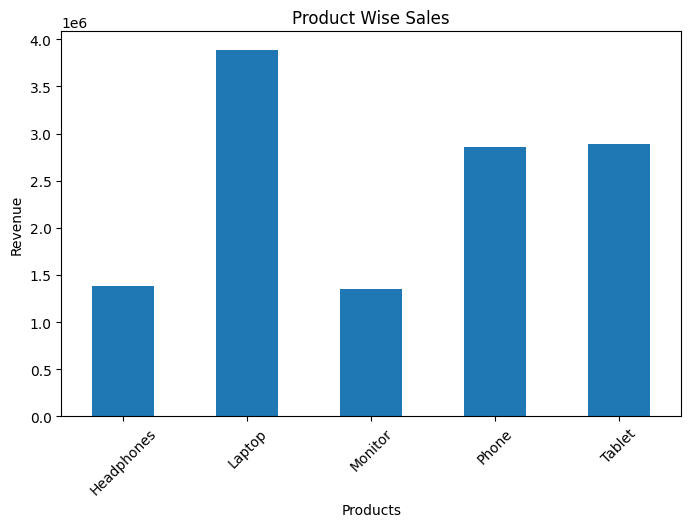

In [16]:
# Product-wise sales bar chart

product_sales = sales_df.groupby("Product")["Total_Sales"].sum()

plt.figure(figsize=(8,5))

product_sales.plot(kind="bar")

plt.title("Product Wise Sales")
plt.xlabel("Products")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.show()

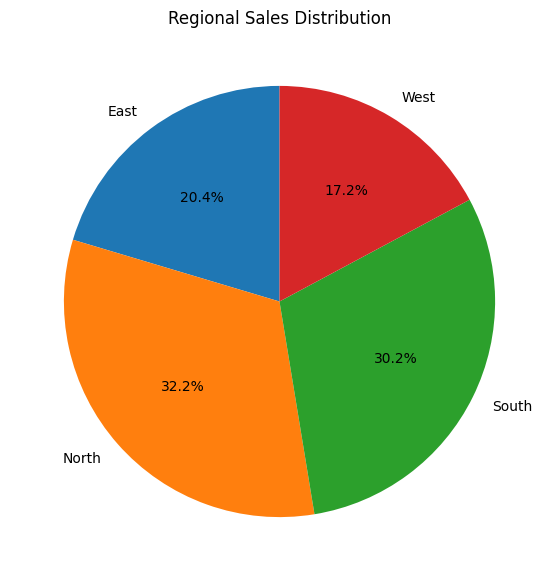

In [17]:
# Regional sales distribution pie chart

region_sales = sales_df.groupby("Region")["Total_Sales"].sum()

plt.figure(figsize=(7,7))

plt.pie(
    region_sales,
    labels=region_sales.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Regional Sales Distribution")

plt.show()

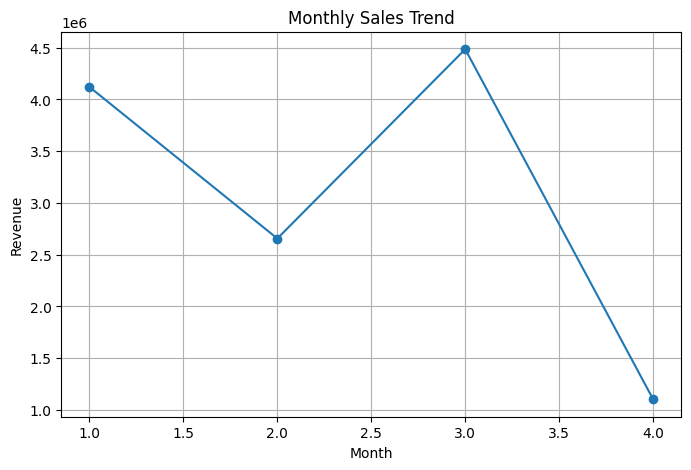

In [18]:
# Monthly sales trend line chart

monthly_sales = sales_df.groupby("Month")["Total_Sales"].sum()

plt.figure(figsize=(8,5))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.grid(True)

plt.show()

In [20]:
# Display final customer sales analysis report

print("=" * 60)
print("CUSTOMER SALES ANALYSIS REPORT")
print("=" * 60)

print(f"Total Revenue        : ₹{total_revenue:,.2f}")
print(f"Average Order Value  : ₹{average_order:,.2f}")
print(f"Best Selling Product : {best_product}")

print("=" * 60)

CUSTOMER SALES ANALYSIS REPORT
Total Revenue        : ₹12,365,048.00
Average Order Value  : ₹123,650.48
Best Selling Product : Laptop
